# Agente Preditivo Especialista — Etapa A (Machine Learning)

**Problema:** a partir dos dados de um beneficiário (idade, sexo, IMC, nº de filhos, se é fumante, região), prever se o **custo do plano de saúde será ALTO** ou **BAIXO/NORMAL**.

A base original (`insurance.csv`) tem como alvo a coluna contínua `charges` (custo em USD). Como esta avaliação exige **Naive Bayes** e as métricas de **acurácia, precisão, sensibilidade e especificidade** — todas próprias de **classificação** — o problema foi reformulado de regressão para **classificação binária**, discretizando o custo pela mediana (ver Célula 4).

**Algoritmos comparados:** Regressão Logística, KNN, MLP e Naive Bayes.

## CÉLULA 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, classification_report)

sns.set_style('whitegrid')

## CÉLULA 2 — Carregar Dataset

In [2]:
URL = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
df = pd.read_csv(URL)
print(f'Shape: {df.shape}')
df.head()

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## CÉLULA 3 — Verificação dos Dados

In [3]:
print('=== INFO ===')
df.info()
print('\n=== NULOS ===')
print(df.isnull().sum())
print('\n=== DUPLICATAS ===')
print(f'Duplicatas encontradas: {df.duplicated().sum()}')
df = df.drop_duplicates().reset_index(drop=True)
print(f'Shape apos remover duplicatas: {df.shape}')
print('\n=== ESTATISTICAS ===')
df.describe()

=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB

=== NULOS ===
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

=== DUPLICATAS ===
Duplicatas encontradas: 1
Shape apos remover duplicatas: (1337, 7)

=== ESTATISTICAS ===


,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


## CÉLULA 4 — Definição do Alvo de Classificação

A base traz o custo (`charges`) como valor contínuo. Para tratar o problema como **classificação**, foi criada a variável alvo **`custo_alto`**:

- `1` (**custo ALTO**) quando `charges` está **acima da mediana**;
- `0` (**custo BAIXO/NORMAL**) caso contrário.

A **mediana** foi escolhida como ponto de corte porque divide a base em duas classes equilibradas (~50%/50%), evitando problemas de desbalanceamento. A coluna `charges` original é descartada das variáveis preditoras (senão o alvo seria trivialmente determinado por ela).

In [4]:
mediana = df['charges'].median()
df['custo_alto'] = (df['charges'] > mediana).astype(int)

print(f'Ponto de corte (mediana de charges): USD {mediana:,.2f}')
print('\nDistribuicao das classes:')
print(df['custo_alto'].value_counts().rename({0: 'Baixo/Normal (0)', 1: 'Alto (1)'}))

Ponto de corte (mediana de charges): USD 9,386.16

Distribuicao das classes:
custo_alto
Baixo/Normal (0)    669
Alto (1)            668
Name: count, dtype: int64


## CÉLULA 5 — Gráfico de Correlação

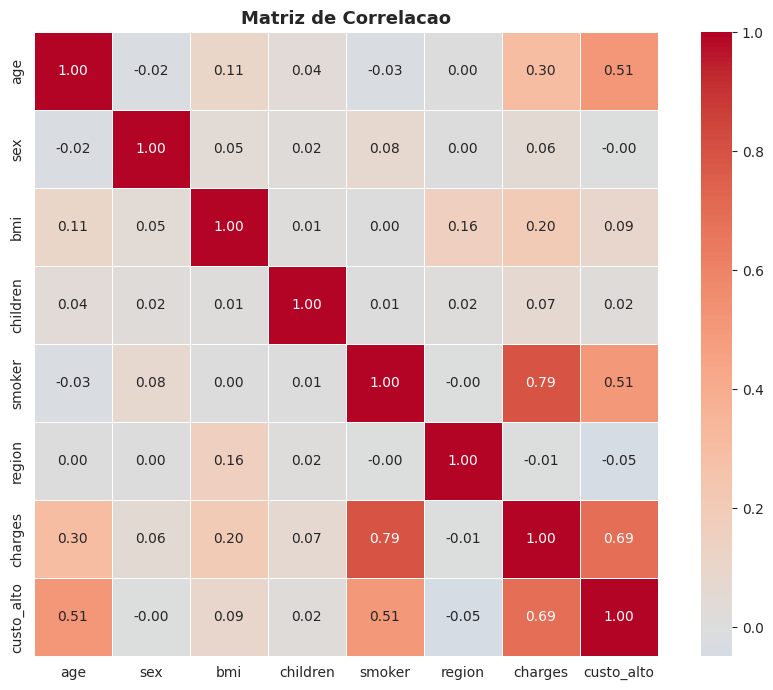

In [5]:
df_corr = df.copy()
le_temp = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df_corr[col] = le_temp.fit_transform(df_corr[col])

plt.figure(figsize=(9, 7))
sns.heatmap(df_corr.corr(numeric_only=True), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=.5)
plt.title('Matriz de Correlacao', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_correlacao.png', bbox_inches='tight', dpi=120)
plt.show()

## CÉLULA 6 — Box Plots

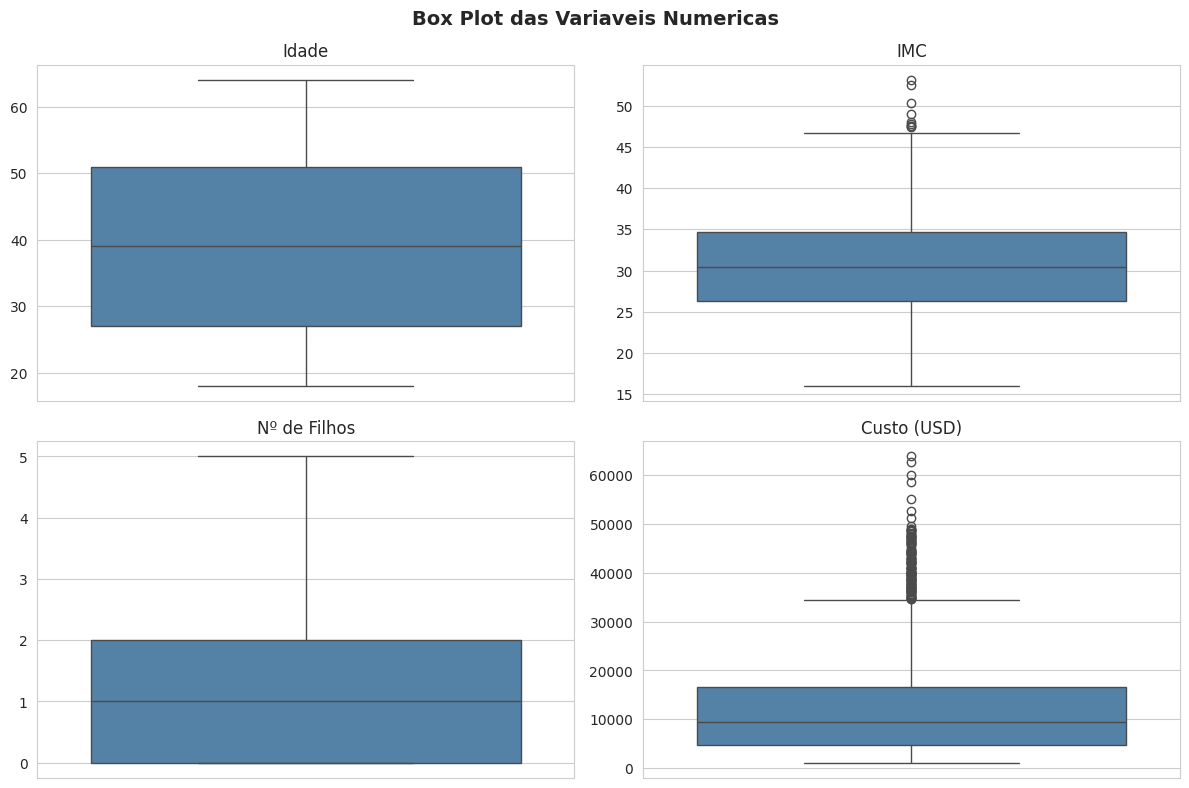

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Box Plot das Variaveis Numericas', fontsize=14, fontweight='bold')

for ax, var, nome in zip(axes.flat,
                         ['age', 'bmi', 'children', 'charges'],
                         ['Idade', 'IMC', 'Nº de Filhos', 'Custo (USD)']):
    sns.boxplot(data=df, y=var, ax=ax, color='steelblue')
    ax.set_title(nome)
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('grafico_boxplot.png', bbox_inches='tight', dpi=120)
plt.show()

## CÉLULA 7 — Gráficos de Frequência

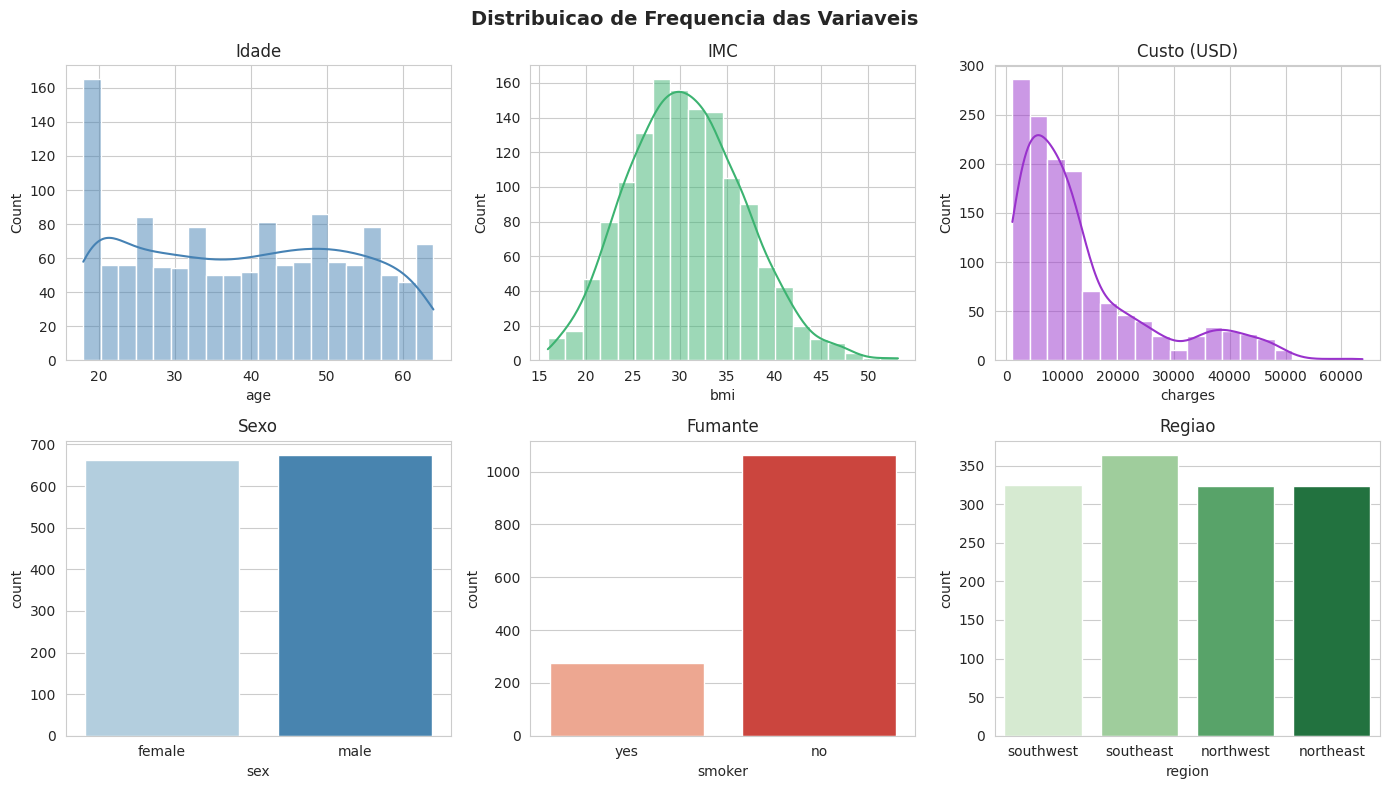

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Distribuicao de Frequencia das Variaveis', fontsize=14, fontweight='bold')

sns.histplot(df['age'], bins=20, kde=True, ax=axes[0, 0], color='steelblue'); axes[0, 0].set_title('Idade')
sns.histplot(df['bmi'], bins=20, kde=True, ax=axes[0, 1], color='mediumseagreen'); axes[0, 1].set_title('IMC')
sns.histplot(df['charges'], bins=20, kde=True, ax=axes[0, 2], color='darkorchid'); axes[0, 2].set_title('Custo (USD)')
sns.countplot(data=df, x='sex', ax=axes[1, 0], palette='Blues'); axes[1, 0].set_title('Sexo')
sns.countplot(data=df, x='smoker', ax=axes[1, 1], palette='Reds'); axes[1, 1].set_title('Fumante')
sns.countplot(data=df, x='region', ax=axes[1, 2], palette='Greens'); axes[1, 2].set_title('Regiao')

plt.tight_layout()
plt.savefig('grafico_frequencia.png', bbox_inches='tight', dpi=120)
plt.show()

## CÉLULA 8 — Relação das Variáveis com o Alvo

Visualização de como as classes (`custo_alto`) se distribuem em relação às principais variáveis. Fica evidente o peso do fato de ser **fumante** e da combinação **idade × IMC** sobre o custo.

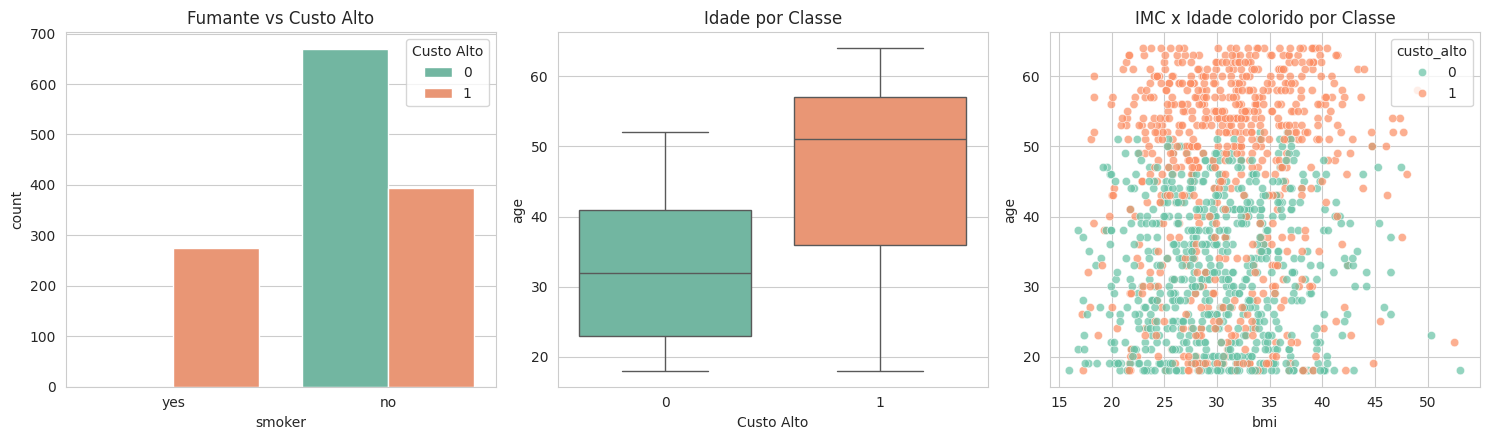

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.countplot(data=df, x='smoker', hue='custo_alto', ax=axes[0], palette='Set2')
axes[0].set_title('Fumante vs Custo Alto'); axes[0].legend(title='Custo Alto')

sns.boxplot(data=df, x='custo_alto', y='age', ax=axes[1], palette='Set2')
axes[1].set_title('Idade por Classe'); axes[1].set_xlabel('Custo Alto')

sns.scatterplot(data=df, x='bmi', y='age', hue='custo_alto', ax=axes[2], palette='Set2', alpha=.7)
axes[2].set_title('IMC x Idade colorido por Classe')

plt.tight_layout()
plt.savefig('grafico_alvo.png', bbox_inches='tight', dpi=120)
plt.show()

## CÉLULA 9 — Pré-processamento

Etapas: codificação das variáveis categóricas (`sex`, `smoker`, `region`) com LabelEncoder, separação treino/teste (80/20, estratificada para manter a proporção das classes) e padronização com StandardScaler. Os encoders e o scaler são guardados para serem reaproveitados pelo backend na Etapa B.

In [9]:
df_model = df.copy()

encoders = {}
for col in ['sex', 'smoker', 'region']:
    enc = LabelEncoder()
    df_model[col] = enc.fit_transform(df_model[col])
    encoders[col] = enc  # guardar mapeamento (ex.: smoker: no->0, yes->1)

X = df_model.drop(['charges', 'custo_alto'], axis=1)
y = df_model['custo_alto']
colunas = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')
print(f'Variaveis preditoras: {colunas}')
for col, enc in encoders.items():
    print(f'  {col}: {dict(zip(enc.classes_, enc.transform(enc.classes_)))}')

Treino: 1069 amostras | Teste: 268 amostras
Variaveis preditoras: ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
  sex: {'female': np.int64(0), 'male': np.int64(1)}
  smoker: {'no': np.int64(0), 'yes': np.int64(1)}
  region: {'northeast': np.int64(0), 'northwest': np.int64(1), 'southeast': np.int64(2), 'southwest': np.int64(3)}


## CÉLULA 10 — Função de Métricas (Classificação)

As quatro métricas exigidas, calculadas a partir da matriz de confusão (classe positiva = **custo alto**):

- **Acurácia** = (VP+VN) / total — acertos gerais
- **Precisão** = VP / (VP+FP) — dos que previu "alto", quantos eram de fato
- **Sensibilidade (Recall)** = VP / (VP+FN) — dos custos altos reais, quantos foram detectados
- **Especificidade** = VN / (VN+FP) — dos custos baixos reais, quantos foram detectados

In [10]:
resultados_finais = []
modelos_treinados = {}

def avaliar_modelo(nome, modelo, y_real, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_real, y_pred).ravel()
    acc  = (tp + tn) / (tp + tn + fp + fn)
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    print(f'\n [{nome}]')
    print(f'  Matriz de confusao: VN={tn} FP={fp} FN={fn} VP={tp}')
    print(f'  Acuracia      : {acc:.4f}')
    print(f'  Precisao      : {prec:.4f}')
    print(f'  Sensibilidade : {sens:.4f}')
    print(f'  Especificidade: {spec:.4f}')
    resultados_finais.append({'Modelo': nome, 'Acuracia': acc, 'Precisao': prec,
                              'Sensibilidade': sens, 'Especificidade': spec})
    modelos_treinados[nome] = modelo
    return y_pred

## CÉLULA 11 — Regressão Logística

> **Nota sobre a Regressão Linear Múltipla:** o enunciado lista "Regressão Linear Múltipla", porém a regressão linear prevê valores contínuos e não produz classes — logo não gera acurácia/especificidade/etc. No contexto de **classificação**, seu equivalente direto é a **Regressão Logística** (mesma base linear, saída em probabilidade de classe). É a opção usada aqui; vale confirmar com o professor se essa adaptação está ok.

In [11]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_sc, y_train)
avaliar_modelo('Regressao Logistica', log_reg, y_test, log_reg.predict(X_test_sc))

print('\nCoeficientes (impacto de cada variavel):')
for col, coef in sorted(zip(colunas, log_reg.coef_[0]), key=lambda x: -abs(x[1])):
    print(f'  {col:10s}: {coef:+.3f}')


 [Regressao Logistica]
  Matriz de confusao: VN=119 FP=15 FN=11 VP=123
  Acuracia      : 0.9030
  Precisao      : 0.8913
  Sensibilidade : 0.9179
  Especificidade: 0.8881

Coeficientes (impacto de cada variavel):
  smoker    : +3.136
  age       : +2.214
  region    : -0.314
  bmi       : +0.186
  children  : +0.167
  sex       : -0.145


## CÉLULA 12 — KNN (testando valores de K)

In [12]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
print(f'{"K":>4}  {"Acuracia":>10}')
print('-' * 18)
acc_por_k = {}
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_sc, y_train)
    acc_por_k[k] = accuracy_score(y_test, knn.predict(X_test_sc))
    print(f'{k:>4}  {acc_por_k[k]:>10.4f}')

melhor_k = max(acc_por_k, key=acc_por_k.get)
print(f'\nMelhor K = {melhor_k} (acuracia = {acc_por_k[melhor_k]:.4f})')

   K    Acuracia
------------------
   1      0.8806
   3      0.9067
   5      0.9104
   7      0.9104
   9      0.9104
  11      0.9104
  15      0.8993
  21      0.8993

Melhor K = 5 (acuracia = 0.9104)


## CÉLULA 13 — KNN (melhor K)

In [13]:
knn_best = KNeighborsClassifier(n_neighbors=melhor_k)
knn_best.fit(X_train_sc, y_train)
avaliar_modelo(f'KNN (K={melhor_k})', knn_best, y_test, knn_best.predict(X_test_sc))


 [KNN (K=5)]
  Matriz de confusao: VN=125 FP=9 FN=15 VP=119
  Acuracia      : 0.9104
  Precisao      : 0.9297
  Sensibilidade : 0.8881
  Especificidade: 0.9328


array([1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0])

## CÉLULA 14 — MLP (testando configurações)

In [14]:
configs_mlp = [
    {'hidden_layer_sizes': (50,),       'activation': 'relu', 'max_iter': 1000},
    {'hidden_layer_sizes': (100,),      'activation': 'relu', 'max_iter': 1000},
    {'hidden_layer_sizes': (100, 100),  'activation': 'relu', 'max_iter': 1000},
    {'hidden_layer_sizes': (100, 50),   'activation': 'tanh', 'max_iter': 1000},
]
print(f'{"Configuracao":>22}  {"Acuracia":>10}')
print('-' * 36)
melhor_cfg, melhor_acc = None, -1
for cfg in configs_mlp:
    mlp = MLPClassifier(random_state=42, **cfg)
    mlp.fit(X_train_sc, y_train)
    a = accuracy_score(y_test, mlp.predict(X_test_sc))
    print(f'{str(cfg["hidden_layer_sizes"])+" "+cfg["activation"]:>22}  {a:>10.4f}')
    if a > melhor_acc:
        melhor_acc, melhor_cfg = a, cfg

print(f'\nMelhor configuracao: {melhor_cfg["hidden_layer_sizes"]} / {melhor_cfg["activation"]}')

          Configuracao    Acuracia
------------------------------------


            (50,) relu      0.9515


           (100,) relu      0.9515


       (100, 100) relu      0.9366


        (100, 50) tanh      0.9366

Melhor configuracao: (50,) / relu


## CÉLULA 15 — MLP (melhor configuração)

In [15]:
mlp_best = MLPClassifier(random_state=42, **melhor_cfg)
mlp_best.fit(X_train_sc, y_train)
avaliar_modelo(f'MLP {melhor_cfg["hidden_layer_sizes"]} {melhor_cfg["activation"]}',
               mlp_best, y_test, mlp_best.predict(X_test_sc))


 [MLP (50,) relu]
  Matriz de confusao: VN=132 FP=2 FN=11 VP=123
  Acuracia      : 0.9515
  Precisao      : 0.9840
  Sensibilidade : 0.9179
  Especificidade: 0.9851


array([1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 1])

## CÉLULA 16 — Naive Bayes

Usado o **GaussianNB**, adequado para variáveis contínuas. O Naive Bayes assume **independência condicional** entre as variáveis — premissa que aqui é violada (idade, IMC e fumante interagem fortemente no custo), o que tende a limitar seu desempenho. Vale observar isso nas métricas.

In [16]:
nb = GaussianNB()
nb.fit(X_train_sc, y_train)
avaliar_modelo('Naive Bayes', nb, y_test, nb.predict(X_test_sc))


 [Naive Bayes]
  Matriz de confusao: VN=134 FP=0 FN=65 VP=69
  Acuracia      : 0.7575
  Precisao      : 1.0000
  Sensibilidade : 0.5149
  Especificidade: 1.0000


array([0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0])

## CÉLULA 17 — Comparação Final

=== COMPARACAO FINAL ===
                     Acuracia  Precisao  Sensibilidade  Especificidade
Modelo                                                                
Regressao Logistica    0.9030    0.8913         0.9179          0.8881
KNN (K=5)              0.9104    0.9297         0.8881          0.9328
MLP (50,) relu         0.9515    0.9840         0.9179          0.9851
Naive Bayes            0.7575    1.0000         0.5149          1.0000


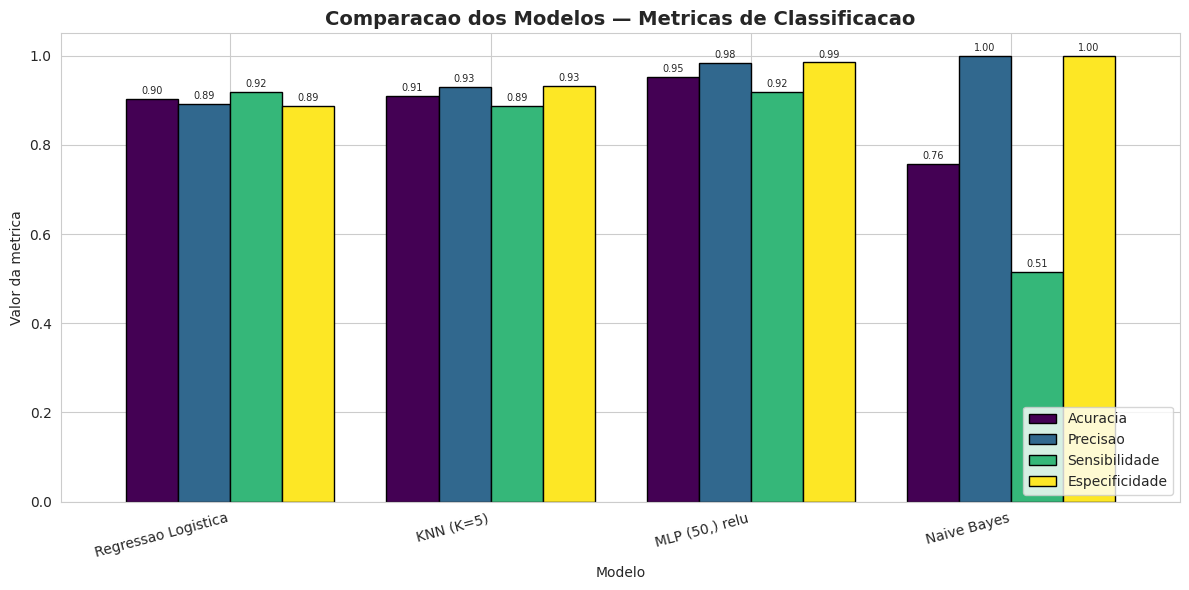


MELHOR MODELO: MLP (50,) relu (acuracia = 0.9515)


In [17]:
df_final = pd.DataFrame(resultados_finais).set_index('Modelo')
print('=== COMPARACAO FINAL ===')
print(df_final.round(4).to_string())

ax = df_final.plot(kind='bar', figsize=(12, 6), width=0.8,
                   colormap='viridis', edgecolor='black')
ax.set_title('Comparacao dos Modelos — Metricas de Classificacao', fontsize=14, fontweight='bold')
ax.set_ylabel('Valor da metrica'); ax.set_ylim(0, 1.05)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.legend(loc='lower right')
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', fontsize=7, padding=2)
plt.tight_layout()
plt.savefig('comparacao_final.png', bbox_inches='tight', dpi=120)
plt.show()

melhor_modelo_nome = df_final['Acuracia'].idxmax()
print(f'\nMELHOR MODELO: {melhor_modelo_nome} '
      f'(acuracia = {df_final.loc[melhor_modelo_nome, "Acuracia"]:.4f})')

## CÉLULA 18 — Exportar o Melhor Modelo

O melhor modelo é exportado **junto com tudo que o backend (Etapa B) precisa** para reproduzir a predição a partir de dados crus: o scaler, os encoders das categóricas, a ordem das colunas e o ponto de corte usado na rotulagem.

In [18]:
melhor_modelo = modelos_treinados[melhor_modelo_nome]

bundle = {
    'modelo': melhor_modelo,
    'modelo_nome': melhor_modelo_nome,
    'scaler': scaler,
    'encoders': encoders,
    'colunas': colunas,
    'ponto_corte_charges': float(mediana),
    'classes': {0: 'Custo Baixo/Normal', 1: 'Custo Alto'},
}
joblib.dump(bundle, 'modelo_agente_preditivo.pkl')
print(f'Modelo "{melhor_modelo_nome}" exportado em: modelo_agente_preditivo.pkl')

# Teste rapido de carregamento + predicao de exemplo
b = joblib.load('modelo_agente_preditivo.pkl')
exemplo = pd.DataFrame([{'age': 45, 'sex': 'male', 'bmi': 31.5,
                         'children': 2, 'smoker': 'yes', 'region': 'southeast'}])
ex = exemplo.copy()
for col, enc in b['encoders'].items():
    ex[col] = enc.transform(ex[col])
ex = ex[b['colunas']]
pred = b['modelo'].predict(b['scaler'].transform(ex))[0]
print(f'Exemplo (fumante, IMC 31.5, 45 anos) -> classe prevista: {b["classes"][int(pred)]}')

Modelo "MLP (50,) relu" exportado em: modelo_agente_preditivo.pkl
Exemplo (fumante, IMC 31.5, 45 anos) -> classe prevista: Custo Alto


## Conclusão

O problema foi tratado como **classificação binária** (custo alto vs. baixo/normal, corte na mediana de `charges`), de modo a permitir o uso do **Naive Bayes** e das métricas exigidas (acurácia, precisão, sensibilidade e especificidade).

**Análise crítica dos quatro algoritmos:**

- **Regressão Logística** — modelo linear, simples e interpretável: os coeficientes mostram diretamente o peso de cada variável (ser *fumante* domina). Bom *baseline*. Limita-se a fronteiras de decisão lineares, não capturando interações complexas entre variáveis.
- **KNN** — não paramétrico, sem treino explícito; sensível à escala (por isso a padronização) e ao valor de K. Custo de inferência cresce com a base. Desempenho competitivo após ajuste de K.
- **MLP** — rede neural capaz de aprender padrões não lineares e interações (ex.: fumante × IMC), normalmente o de melhor desempenho. Em contrapartida, exige normalização, maior custo computacional e ajuste de hiperparâmetros, além de ser pouco interpretável.
- **Naive Bayes** — rápido e robusto com poucos dados, mas assume **independência entre as variáveis**, premissa violada neste problema (idade, IMC e fumante são correlacionados/interagentes). Isso costuma se refletir em **menor sensibilidade** — ele deixa de detectar parte dos casos de custo alto — apesar de alta precisão. É o exemplo didático de como uma premissa irreal degrada o resultado.

O modelo com a melhor acurácia foi exportado em `modelo_agente_preditivo.pkl`, pronto para ser consumido pelo backend (Etapa B) e exposto na interface (Etapa C).

**Sugestões de melhoria:** validação cruzada (K-Fold) para estimativas mais robustas; *GridSearchCV* para tunar hiperparâmetros; *feature engineering* (ex.: variável de interação `bmi × smoker`); e testar limiares alternativos de corte do custo conforme o objetivo de negócio.